Завантаж свій MP3/WAV файл (c-major-scale.mp3 або інший)


Saving c-major-scale.mp3 to c-major-scale (3).mp3

Обробка: c-major-scale (3).mp3

Форма активацій: (310, 88, 3)

Список нот:


,start_sec,end_sec,duration_sec,midi_pitch,note_name,velocity
0,0.00,0.21,0.21,48,C3,125
14,0.00,0.19,0.19,60,C4,59
23,0.00,0.04,0.04,79,G5,113
2,0.19,0.40,0.21,50,D3,123
17,0.30,0.38,0.08,62,D4,55
24,0.31,0.39,0.08,79,G5,54
20,0.39,0.48,0.09,71,B4,101
4,0.39,0.59,0.20,52,E3,126
27,0.48,0.58,0.10,80,G#5,56
21,0.54,0.58,0.04,71,B4,59



Унікальні ноти: ['A3', 'B3', 'B4', 'C3', 'C4', 'D3', 'D4', 'E3', 'F3', 'G#5', 'G3', 'G4', 'G5']
Кількість нот: 29
Тривалість: 3.09 сек


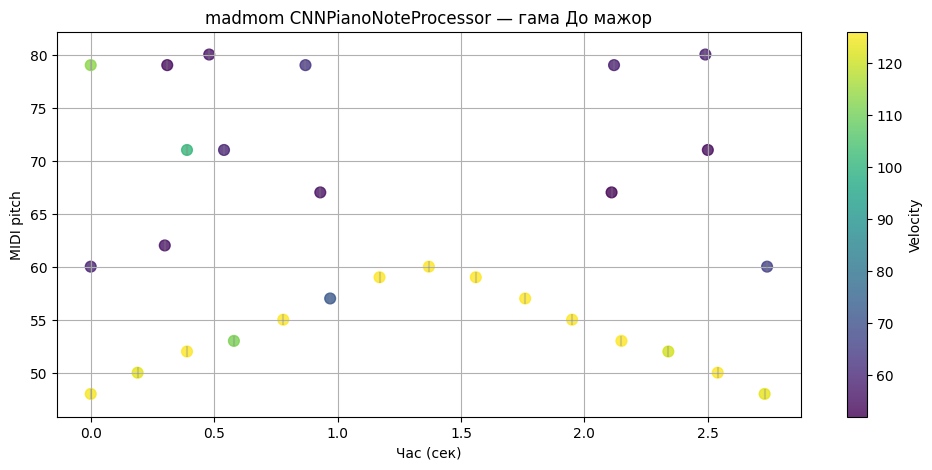

MIDI збережено як: madmom_c_major_scale.mid


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
!pip install madmom pretty-midi pandas matplotlib -q

from google.colab import files
import madmom
from madmom.features.notes import CNNPianoNoteProcessor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pretty_midi

print("Завантаж свій MP3/WAV файл (c-major-scale.mp3 або інший)")
uploaded = files.upload()

if not uploaded:
    raise ValueError("Файл не завантажено — спробуй ще раз")

audio_file = list(uploaded.keys())[0]
print(f"\nОбробка: {audio_file}")

note_processor = CNNPianoNoteProcessor()
activations = note_processor(audio_file)

print("\nФорма активацій:", activations.shape)

onset_channel = 0
threshold = 0.4          # 0.4–0.6 для чистоти
min_duration_frames = 5  # мінімум кадрів для ноти
frame_duration = 0.01

onset_probs = activations[:, :, onset_channel]
time_steps = np.arange(activations.shape[0]) * frame_duration

detected_notes = []
for pitch in range(88):
    prob_sequence = onset_probs[:, pitch]
    in_note = False
    start_frame = None
    max_prob = 0

    for frame in range(len(prob_sequence)):
        prob = prob_sequence[frame]
        if prob > threshold and not in_note:
            in_note = True
            start_frame = frame
            max_prob = prob
        elif (prob <= threshold or frame == len(prob_sequence)-1) and in_note:
            in_note = False
            end_frame = frame - 1
            duration_frames = end_frame - start_frame + 1

            if duration_frames >= min_duration_frames:
                start_sec = time_steps[start_frame]
                end_sec = time_steps[end_frame]
                duration_sec = end_sec - start_sec
                midi_pitch = pitch + 21
                velocity = int(max_prob * 127)

                detected_notes.append([
                    start_sec, end_sec, duration_sec, midi_pitch,
                    pretty_midi.note_number_to_name(midi_pitch),
                    velocity
                ])
            max_prob = 0

if not detected_notes:
    print("Нот не виявлено — спробуй threshold=0.3 або перевір аудіо")
else:
    df = pd.DataFrame(detected_notes, columns=['start_sec', 'end_sec', 'duration_sec', 'midi_pitch', 'note_name', 'velocity'])
    df = df.astype({'start_sec': float, 'end_sec': float, 'duration_sec': float, 'midi_pitch': int, 'velocity': int})

    print("\nСписок нот:")
    display(df.sort_values('start_sec'))

    print("\nУнікальні ноти:", sorted(df['note_name'].unique()))
    print(f"Кількість нот: {len(df)}")
    print(f"Тривалість: {time_steps[-1]:.2f} сек")

    plt.figure(figsize=(12, 5))
    plt.scatter(df['start_sec'], df['midi_pitch'], s=60, c=df['velocity'], cmap='viridis', alpha=0.8)
    plt.vlines(df['start_sec'], ymin=df['midi_pitch']-0.5, ymax=df['midi_pitch']+0.5, colors='gray', alpha=0.3)
    plt.colorbar(label='Velocity')
    plt.xlabel('Час (сек)')
    plt.ylabel('MIDI pitch')
    plt.title('madmom CNNPianoNoteProcessor — гама До мажор')
    plt.grid(True)
    plt.show()

    midi = pretty_midi.PrettyMIDI()
    piano = pretty_midi.Instrument(program=0)

    for row in df.itertuples():
        note = pretty_midi.Note(
            velocity=int(row.velocity),
            pitch=int(row.midi_pitch),
            start=row.start_sec,
            end=row.end_sec
        )
        piano.notes.append(note)

    midi.instruments.append(piano)

    midi_filename = "madmom_c_major_scale.mid"
    midi.write(midi_filename)
    print(f"MIDI збережено як: {midi_filename}")

    files.download(midi_filename)